# 01 — Exploratory Data Analysis
Understand the dataset: class imbalance, feature distributions, correlation.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.173%


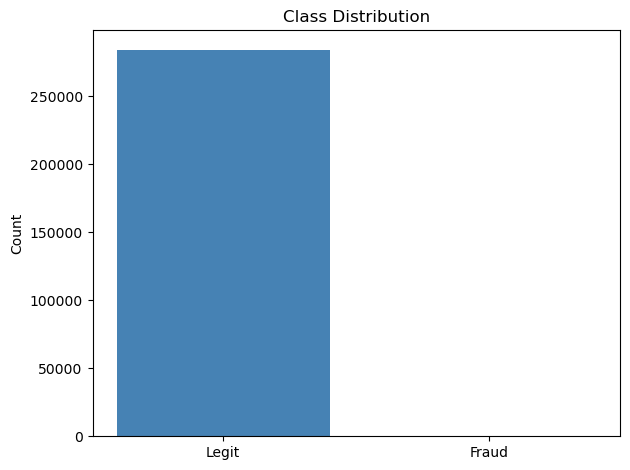

In [2]:
# Class balance
counts = df['Class'].value_counts()
print(counts)
print(f"Fraud rate: {counts[1]/len(df)*100:.3f}%")

fig, ax = plt.subplots()
ax.bar(['Legit', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

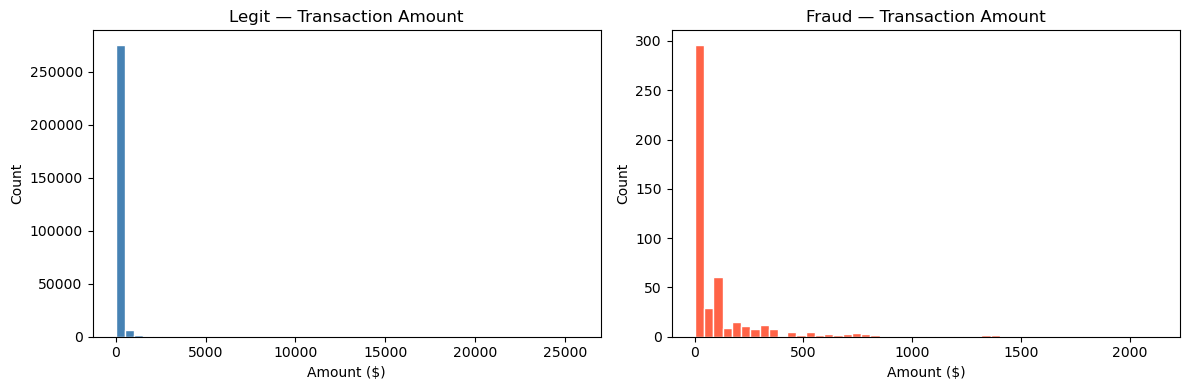

In [3]:
# Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls, ax, label, color in zip([0, 1], axes, ['Legit', 'Fraud'], ['steelblue', 'tomato']):
    subset = df[df['Class'] == cls]['Amount']
    ax.hist(subset, bins=50, color=color, edgecolor='white')
    ax.set_title(f'{label} — Transaction Amount')
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../results/figures/amount_by_class.png', dpi=150)
plt.show()

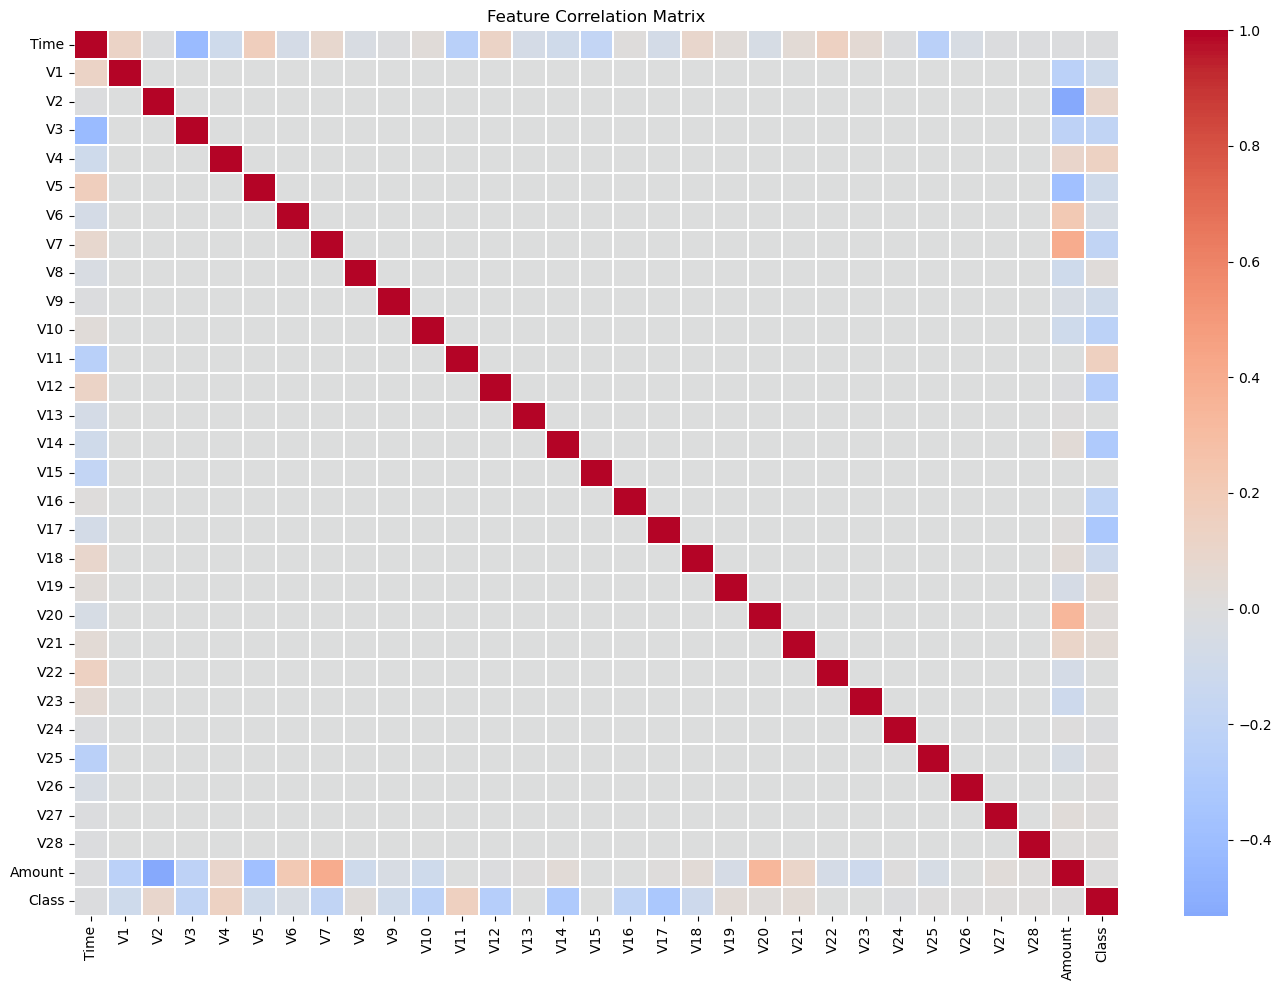

In [4]:
# Correlation heatmap (sample to keep it readable)
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/figures/correlation_heatmap.png', dpi=150)
plt.show()

In [5]:
# Features most correlated with Class
top_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
print('Top 10 features correlated with fraud:')
print(top_corr)

Top 10 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64
